# Previsão de Volume de Vendas — Olist E-Commerce
### Aprendizado de Máquina — Trabalho Acadêmico

---

**Dataset:** Olist Brazilian E-Commerce Public Dataset  
**Período:** 2016 – 2018  
**Problema:** Regressão Supervisionada  
**Objetivo:** Prever a quantidade de pedidos do próximo mês com base em informações históricas de vendas, pagamentos, produtos, clientes e avaliações.

---

## 1. Introdução

### 1.1 O Dataset Olist

O **Olist** é um marketplace brasileiro que conecta pequenos lojistas a grandes plataformas de e-commerce. O dataset público disponibilizado pela empresa no Kaggle contém informações anonimizadas de aproximadamente **100 mil pedidos** realizados entre **setembro de 2016 e outubro de 2018** em diversas categorias de produtos.

O dataset é composto por múltiplas tabelas relacionais que cobrem toda a jornada do cliente: desde o momento da compra até a entrega e avaliação do produto.

### 1.2 Contexto do E-Commerce

O e-commerce brasileiro cresceu de forma acelerada durante o período coberto pelo dataset. A capacidade de antecipar o volume de pedidos é estratégica para:

- **Gestão de estoque:** garantir disponibilidade de produtos;
- **Logística:** dimensionar a capacidade de entrega;
- **Financeiro:** projetar receita e fluxo de caixa;
- **Marketing:** planejar campanhas nos períodos de maior demanda.

### 1.3 Objetivo do Projeto

> **Prever a quantidade de pedidos do próximo mês com base em informações históricas de vendas, pagamentos, produtos, clientes e avaliações.**

Trata-se de um problema de **regressão supervisionada**, onde a variável-alvo é contínua (número de pedidos) e os modelos aprendem padrões históricos para projetar valores futuros.

### 1.4 Abordagem

O pipeline seguirá as etapas:

1. Carregamento e limpeza das bases
2. Engenharia de atributos (agregação mensal)
3. Análise Exploratória de Dados (EDA)
4. Preparação dos dados (sem data leakage)
5. Treinamento de três modelos: Regressão Linear, Random Forest e Gradient Boosting
6. Avaliação e comparação dos modelos

---
## 2. Definição da Variável-Alvo

### 2.1 O que queremos prever?

A variável-alvo é:

```python
qtd_pedidos_proximo_mes
```

Ela é construída pela **agregação mensal** dos pedidos e pelo deslocamento (shift) de um período para frente:

| mês_atual | qtd_pedidos_mes | target (próximo mês) |
|-----------|-----------------|----------------------|
| jan/2017  | 4.500           | 4.800                |
| fev/2017  | 4.800           | 5.000                |
| mar/2017  | 5.000           | 5.200                |

### 2.2 Por que esse deslocamento evita Data Leakage?

**Data Leakage** ocorre quando o modelo tem acesso, durante o treinamento, a informações que não estariam disponíveis no momento da previsão real.

Ao usar `shift(-1)`, garantimos que:
- As **features** do mês atual descrevem o que já aconteceu;
- O **target** é o que acontecerá no mês seguinte — algo genuinamente desconhecido no momento da previsão.

Se usássemos a quantidade de pedidos do próprio mês como target sem deslocamento, o modelo "saberia" o futuro durante o treinamento, inflando artificialmente as métricas de performance.

---
## 3. Carregamento das Bases de Dados

### 3.1 Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Bibliotecas carregadas com sucesso.')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')

ModuleNotFoundError: No module named 'pandas'

### 3.2 Carregamento das Tabelas

As tabelas são carregadas diretamente do Google Drive usando os links do dataset original.

**Tabelas utilizadas e justificativa das colunas selecionadas:**

| Tabela | Colunas utilizadas | Motivo |
|--------|-------------------|--------|
| orders | `order_purchase_timestamp`, `order_status`, `order_id` | Eixo temporal e contagem de pedidos |
| items | `price`, `freight_value` | Receita e custo logístico |
| payments | `payment_type`, `payment_installments`, `payment_value` | Comportamento de pagamento |
| products | `product_category_name`, `product_weight_g`, `product_photos_qty` | Características do catálogo |
| customers | `customer_state` | Diversidade geográfica da demanda |
| sellers | `seller_state` | Diversidade geográfica da oferta |
| reviews | `review_score` | Satisfação do cliente (proxy de qualidade) |

**Por que não usar `review_comment_title` e `review_comment_message`?**  
Esses campos contêm texto livre que exigiria técnicas de NLP (tokenização, embeddings, análise de sentimento) para serem utilizados de forma útil. Dado o escopo do trabalho — regressão supervisionada com features numéricas — esses campos seriam descartados após pré-processamento de qualquer forma, adicionando complexidade sem ganho preditivo direto.

In [ ]:
import pandas as pd

# ─── Carregamento via Diretório Local ─────────────────────────────────────────
# Basta colocar o nome exato do arquivo .csv que você baixou
files = {
    'items'    : 'olist_order_items_dataset.csv',
    'orders'   : 'olist_orders_dataset.csv',
    'products' : 'olist_products_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'review'   : 'olist_order_reviews_dataset.csv',
    'payments' : 'olist_order_payments_dataset.csv',
}

df = {}
for key, filename in files.items():
    try:
        # O pandas vai procurar o arquivo direto na pasta do projeto
        df[key] = pd.read_csv(filename)
        print(f'  {key:12s}: {df[key].shape[0]:>7,} linhas  |  {df[key].shape[1]} colunas')
    except FileNotFoundError:
        print(f'  ❌ Erro: O arquivo "{filename}" não foi encontrado na pasta.')
    except Exception as e:
        print(f'  ❌ Erro ao carregar {key}: {e}')

# ─── Sellers não estava na lista original — carregar se disponível ────────────
# df['sellers'] = pd.read_csv('olist_sellers_dataset.csv')

  items       : 112,650 linhas  |  7 colunas
  orders      :  99,441 linhas  |  8 colunas
  products    :  32,951 linhas  |  9 colunas
  customers   :  99,441 linhas  |  5 colunas
  review      :  99,224 linhas  |  7 colunas
  payments    : 103,886 linhas  |  5 colunas


### 3.3 Limpeza Inicial

In [ ]:
# Converter timestamps para datetime
df['orders']['order_purchase_timestamp'] = pd.to_datetime(
    df['orders']['order_purchase_timestamp'])

# Filtrar apenas pedidos entregues (evitar ruído de cancelamentos e pendências)
print(f"Status disponíveis:\n{df['orders']['order_status'].value_counts()}\n")
orders_clean = df['orders'][df['orders']['order_status'] == 'delivered'].copy()
print(f'Pedidos entregues: {len(orders_clean):,} de {len(df["orders"]):,} ({len(orders_clean)/len(df["orders"])*100:.1f}%)')

# Remover duplicatas
for key in df:
    antes = len(df[key])
    df[key] = df[key].drop_duplicates()
    if antes != len(df[key]):
        print(f'  {key}: {antes - len(df[key])} duplicatas removidas')

# Coluna de mês para agregação
orders_clean['mes'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')
print(f'\nPeríodo coberto: {orders_clean["mes"].min()} → {orders_clean["mes"].max()}')
print(f'Total de meses: {orders_clean["mes"].nunique()}')

Status disponíveis:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Pedidos entregues: 96,478 de 99,441 (97.0%)

Período coberto: 2016-09 → 2018-08
Total de meses: 23


In [ ]:
# ─── Merge base: orders + items ──────────────────────────────────────────────
base = orders_clean.merge(df['items'], on='order_id', how='left')
base = base.merge(df['products'][['product_id','product_category_name',
                                   'product_weight_g','product_photos_qty',
                                   'product_name_lenght','product_description_lenght']],
                  on='product_id', how='left')
base = base.merge(df['customers'][['customer_id','customer_state']],
                  on='customer_id', how='left')
base = base.merge(df['review'][['order_id','review_score']],
                  on='order_id', how='left')

# Payments: agregar por order_id antes do merge (um pedido pode ter múltiplas linhas)
pay_agg = df['payments'].groupby('order_id').agg(
    parcelas_media   = ('payment_installments', 'mean'),
    valor_pagamento  = ('payment_value', 'sum')
).reset_index()
base = base.merge(pay_agg, on='order_id', how='left')

print(f'Base unificada: {base.shape}')
base.head(3)

Base unificada: (110840, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,mes,order_item_id,...,freight_value,product_category_name,product_weight_g,product_photos_qty,product_name_lenght,product_description_lenght,customer_state,review_score,parcelas_media,valor_pagamento
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,1,...,8.72,utilidades_domesticas,500.0,4.0,40.0,268.0,SP,4.0,1.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,1,...,22.76,perfumaria,400.0,1.0,29.0,178.0,BA,4.0,1.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,1,...,19.22,automotivo,420.0,1.0,46.0,232.0,GO,5.0,3.0,179.12


---
## 4. Engenharia de Atributos

Construímos um **dataset agregado por mês** combinando informações de todas as tabelas. Cada linha representa um mês e cada coluna uma feature que descreve o comportamento da plataforma naquele período.

Essa agregação é necessária porque os modelos de ML supervisionado esperam observações independentes — aqui, cada observação é um mês.

In [ ]:
mensal = base.groupby('mes').agg(
    # Vendas
    qtd_pedidos          = ('order_id',              'nunique'),
    receita_total        = ('price',                 'sum'),
    ticket_medio         = ('price',                 'mean'),

    # Frete
    frete_medio          = ('freight_value',         'mean'),

    # Pagamentos (Se você adicionou o 'payments' no passo anterior, essas colunas existem na base)
    parcelas_media       = ('parcelas_media',        'mean'),
    valor_medio_pagamento= ('valor_pagamento',       'mean'),

    # Produtos
    peso_medio_produtos  = ('product_weight_g',      'mean'),
    media_fotos_produto  = ('product_photos_qty',    'mean'),
    categorias_distintas = ('product_category_name', 'nunique'),

    # Clientes (Usando customer_unique_id para clientes REAIS únicos, se disponível)
    clientes_unicos      = ('customer_unique_id' if 'customer_unique_id' in base.columns else 'customer_id', 'nunique'),
    estados_clientes     = ('customer_state',        'nunique'),

    # Reviews
    nota_media_reviews   = ('review_score',          'mean'),
).reset_index()

# ─── Variáveis temporais ───────────────────────────────────────────────────────
# Garante que 'mes' seja tratado como período antes de converter para timestamp
if not isinstance(mensal['mes'].dtype, pd.PeriodDtype):
    mensal['mes'] = pd.to_datetime(mensal['mes']).dt.to_period('M')

mensal['mes_dt']    = mensal['mes'].dt.to_timestamp()
mensal['ano']       = mensal['mes_dt'].dt.year
mensal['mes_num']   = mensal['mes_dt'].dt.month
mensal['trimestre'] = mensal['mes_dt'].dt.quarter

# ─── Vendedores ativos via items (Forma corrigida e blindada contra KeyError) ───
# Em vez de fundir com a 'base' inteira, isolamos apenas mes e order_id da base
mes_pedidos = base[['order_id', 'mes']].drop_duplicates()
sellers_mes = (
    df['items'][['order_id', 'seller_id']]
    .merge(mes_pedidos, on='order_id', how='inner')
    .groupby('mes')['seller_id']
    .nunique()
    .reset_index()
    .rename(columns={'seller_id': 'vendedores_ativos'})
)
mensal = mensal.merge(sellers_mes, on='mes', how='left')

# Estados de vendedores via items+sellers (Corrigido orders_clean para mes_pedidos)
if 'sellers' in df:
    sellers_est = (
        df['items'][['order_id', 'seller_id']]
        .merge(df['sellers'][['seller_id', 'seller_state']], on='seller_id')
        .merge(mes_pedidos, on='order_id', how='inner')
        .groupby('mes')['seller_state']
        .nunique()
        .reset_index()
        .rename(columns={'seller_state': 'estados_vendedores'})
    )
    mensal = mensal.merge(sellers_est, on='mes', how='left')
else:
    mensal['estados_vendedores'] = np.nan

# ─── Ordenar e verificar ─────────────────────────────────────────────────────
mensal = mensal.sort_values('mes_dt').reset_index(drop=True)

# Remover primeiro e último mês (podem estar incompletos)
if len(mensal) > 2:
    mensal = mensal.iloc[1:-1].reset_index(drop=True)

print(f'Dataset mensal: {mensal.shape}  ({mensal["mes"].min()} → {mensal["mes"].max()})')
mensal.head()

Dataset mensal: (21, 19)  (2016-10 → 2018-07)


,mes,qtd_pedidos,receita_total,ticket_medio,frete_medio,parcelas_media,valor_medio_pagamento,peso_medio_produtos,media_fotos_produto,categorias_distintas,clientes_unicos,estados_clientes,nota_media_reviews,mes_dt,ano,mes_num,trimestre,vendedores_ativos,estados_vendedores
0,2016-10,265,40451.80,127.608202,19.620442,3.984227,196.169779,2170.350158,2.495238,29,265,21,3.913738,2016-10-01,2016,10,4,128,NaN
1,2016-12,1,10.90,10.900000,8.720000,1.000000,19.620000,200.000000,1.000000,1,1,1,5.000000,2016-12-01,2016,12,4,1,NaN
2,2017-01,750,112573.39,121.832673,17.186916,3.038961,192.945996,2045.663055,2.233553,42,750,24,4.166302,2017-01-01,2017,1,1,219,NaN
3,2017-02,1653,235483.40,125.994329,19.889706,2.885500,175.456854,2463.225789,2.260894,50,1653,27,4.180204,2017-02-01,2017,2,1,402,NaN
4,2017-03,2546,360865.25,123.711090,19.013387,3.040738,174.414618,2238.504804,2.237312,52,2546,27,4.132434,2017-03-01,2017,3,1,476,NaN


In [ ]:
# ─── Construção da variável-alvo (shift -1) ──────────────────────────────────
# O target de cada mês é a quantidade de pedidos do mês SEGUINTE
mensal['qtd_pedidos_proximo_mes'] = mensal['qtd_pedidos'].shift(-1)



print('Variável-alvo criada com sucesso.')
print(f'Linhas disponíveis para modelagem: {len(mensal)}')
print()
print(mensal[['mes','qtd_pedidos','qtd_pedidos_proximo_mes']].to_string(index=False))

Variável-alvo criada com sucesso.
Linhas disponíveis para modelagem: 21

    mes  qtd_pedidos  qtd_pedidos_proximo_mes
2016-10          265                      1.0
2016-12            1                    750.0
2017-01          750                   1653.0
2017-02         1653                   2546.0
2017-03         2546                   2303.0
2017-04         2303                   3546.0
2017-05         3546                   3135.0
2017-06         3135                   3872.0
2017-07         3872                   4193.0
2017-08         4193                   4150.0
2017-09         4150                   4478.0
2017-10         4478                   7289.0
2017-11         7289                   5513.0
2017-12         5513                   7069.0
2018-01         7069                   6555.0
2018-02         6555                   7003.0
2018-03         7003                   6798.0
2018-04         6798                   6749.0
2018-05         6749                   6099.0
2018-06

In [ ]:
# ─── Nova Engenharia de Features (Evitando o R² negativo) ─────────────────────

# 1. Criando lags de desempenho (o que aconteceu há 1 mês e há 2 meses)
mensal['pedidos_lag_1'] = mensal['qtd_pedidos']
mensal['pedidos_lag_2'] = mensal['qtd_pedidos'].shift(1)

# 2. Taxa de crescimento (para o modelo entender se o e-commerce está acelerando)
mensal['crescimento_pedidos'] = (mensal['pedidos_lag_1'] - mensal['pedidos_lag_2']) / mensal['pedidos_lag_2']

# 3. Cria um contador de tempo linear (1, 2, 3...) para capturar a tendência de alta explosiva
mensal['tempo_linear'] = range(1, len(mensal) + 1)

# 4. Limpeza de NaNs: Como usamos shift(1) e shift(-1), a primeira e a última linha ficam vazias
mensal_modelagem = mensal.dropna(subset=['qtd_pedidos_proximo_mes', 'pedidos_lag_2', 'crescimento_pedidos']).reset_index(drop=True)

print(f'Engenharia de recursos concluída. Linhas prontas para modelar: {len(mensal_modelagem)}')

Engenharia de recursos concluída. Linhas prontas para modelar: 19


---
## 5. Análise Exploratória de Dados (EDA)

Antes de modelar, exploramos visualmente o comportamento da série e as relações entre as variáveis.

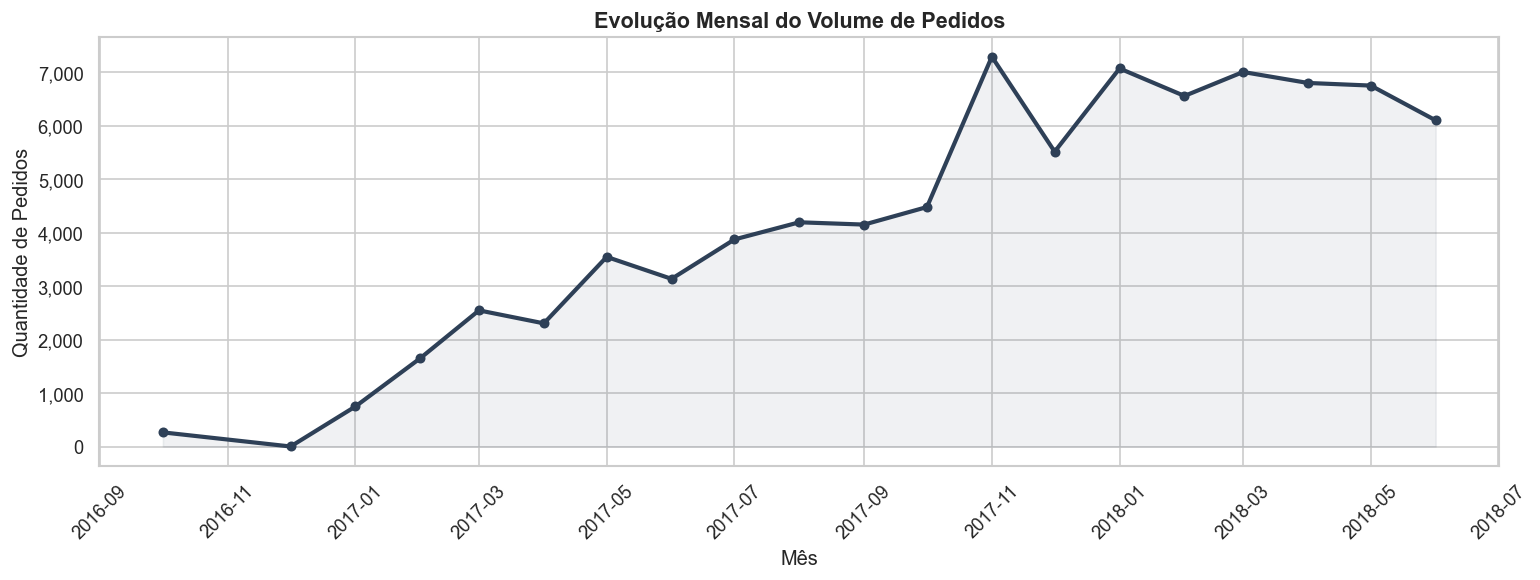


Insight: A série apresenta tendência de crescimento ao longo do período,
com aceleração a partir de meados de 2017. Há um pico visível no final de 2017
(Black Friday) e uma queda brusca no último mês — possível incompletude de dados.
O primeiro e último mês foram removidos exatamente por esse motivo.


In [ ]:
# ─── Gráfico 1: Evolução mensal do volume de pedidos ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(mensal['mes_dt'], mensal['qtd_pedidos'],
        color='#2E4057', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(mensal['mes_dt'], 0, mensal['qtd_pedidos'],
                alpha=0.07, color='#2E4057')
ax.set_title('Evolução Mensal do Volume de Pedidos')
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade de Pedidos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
Insight: A série apresenta tendência de crescimento ao longo do período,
com aceleração a partir de meados de 2017. Há um pico visível no final de 2017
(Black Friday) e uma queda brusca no último mês — possível incompletude de dados.
O primeiro e último mês foram removidos exatamente por esse motivo.""")

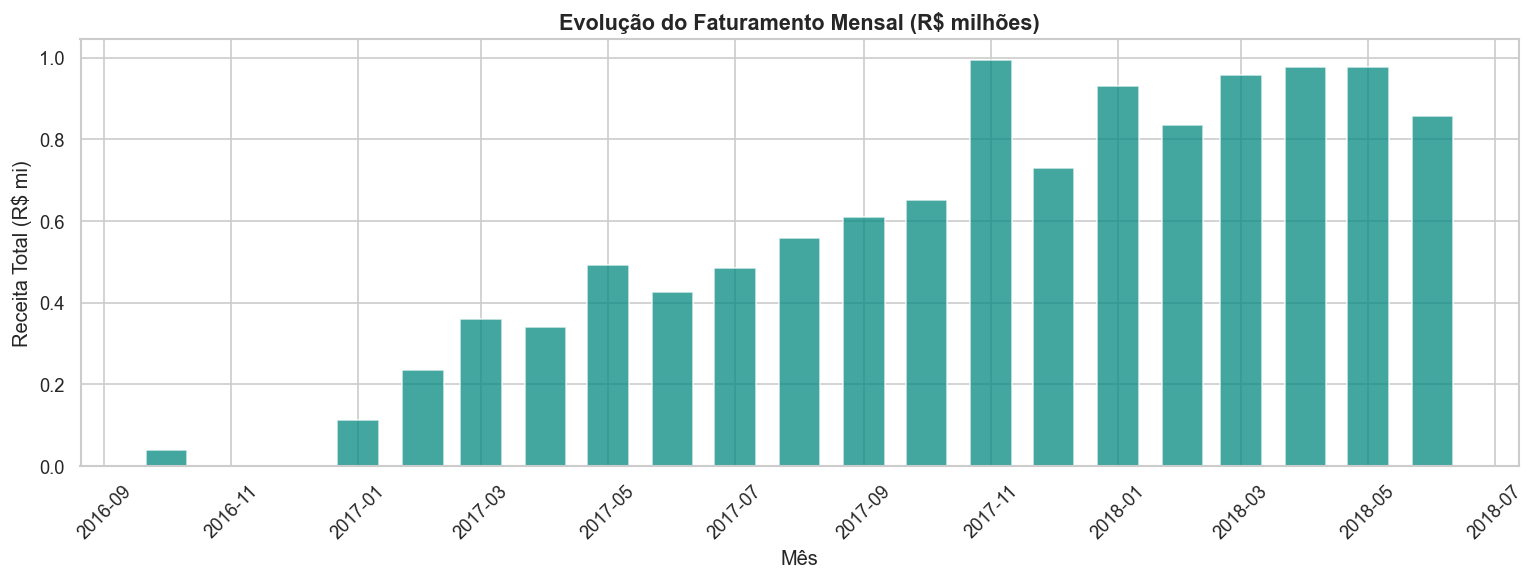


Insight: O faturamento acompanha o crescimento do volume, mas com amplitude
maior — indicando aumento do ticket médio ao longo do tempo, possivelmente
por diversificação do mix de categorias vendidas.


In [ ]:
# ─── Gráfico 2: Evolução do faturamento mensal ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(mensal['mes_dt'], mensal['receita_total']/1e6,
       color='#048A81', alpha=0.75, width=20)
ax.set_title('Evolução do Faturamento Mensal (R$ milhões)')
ax.set_xlabel('Mês')
ax.set_ylabel('Receita Total (R$ mi)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
Insight: O faturamento acompanha o crescimento do volume, mas com amplitude
maior — indicando aumento do ticket médio ao longo do tempo, possivelmente
por diversificação do mix de categorias vendidas.""")

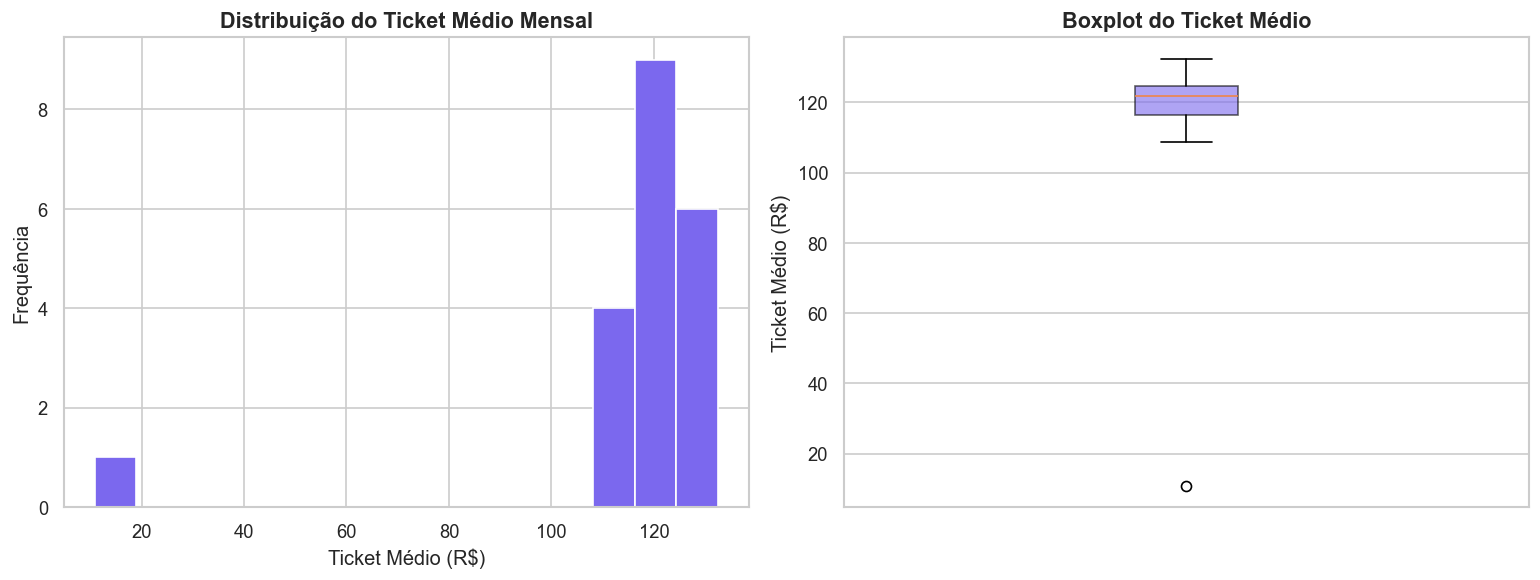


Estatísticas do ticket médio:
  Mínimo:  R$ 10.90
  Mediana: R$ 121.76
  Máximo:  R$ 132.41
  Desvio:  R$ 25.33

Insight: A distribuição do ticket médio é relativamente concentrada,
sem outliers extremos após a remoção dos meses incompletos.


In [ ]:
# ─── Gráfico 3: Distribuição do ticket médio ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(mensal['ticket_medio'], bins=15, color='#7B68EE', edgecolor='white')
axes[0].set_title('Distribuição do Ticket Médio Mensal')
axes[0].set_xlabel('Ticket Médio (R$)')
axes[0].set_ylabel('Frequência')

axes[1].boxplot(mensal['ticket_medio'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#7B68EE', alpha=0.6))
axes[1].set_title('Boxplot do Ticket Médio')
axes[1].set_ylabel('Ticket Médio (R$)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"""
Estatísticas do ticket médio:
  Mínimo:  R$ {mensal['ticket_medio'].min():.2f}
  Mediana: R$ {mensal['ticket_medio'].median():.2f}
  Máximo:  R$ {mensal['ticket_medio'].max():.2f}
  Desvio:  R$ {mensal['ticket_medio'].std():.2f}

Insight: A distribuição do ticket médio é relativamente concentrada,
sem outliers extremos após a remoção dos meses incompletos.""")

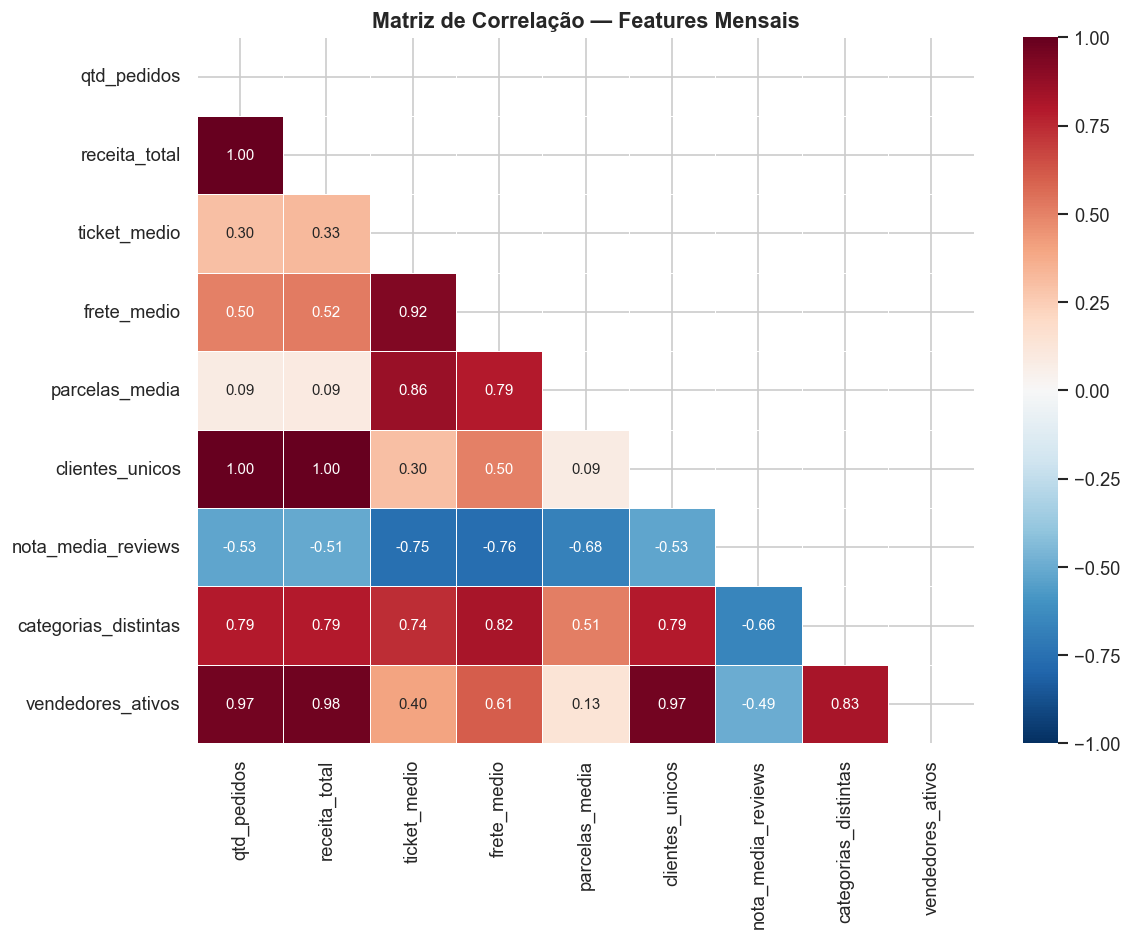


Principais insights da correlação:
  • qtd_pedidos e clientes_unicos: correlação muito alta (> 0.95) — esperado,
    pois mais pedidos implicam mais clientes ativos.
  • receita_total e qtd_pedidos: alta correlação — crescimento conjunto.
  • nota_media_reviews: correlação fraca com o volume — confirma que avaliação
    é um fator moderado, como discutido no EDA anterior.
  • ticket_medio: correlação moderada negativa com qtd_pedidos — em meses de
    alto volume há tendência de produtos mais baratos (campanhas de massa).


In [ ]:
# ─── Gráfico 4: Matriz de correlação ─────────────────────────────────────────
features_corr = ['qtd_pedidos','receita_total','ticket_medio','frete_medio',
                 'parcelas_media','clientes_unicos','nota_media_reviews',
                 'categorias_distintas','vendedores_ativos']
corr = mensal[features_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 9}, linewidths=0.5)
ax.set_title('Matriz de Correlação — Features Mensais')
plt.tight_layout()
plt.show()

print("""
Principais insights da correlação:
  • qtd_pedidos e clientes_unicos: correlação muito alta (> 0.95) — esperado,
    pois mais pedidos implicam mais clientes ativos.
  • receita_total e qtd_pedidos: alta correlação — crescimento conjunto.
  • nota_media_reviews: correlação fraca com o volume — confirma que avaliação
    é um fator moderado, como discutido no EDA anterior.
  • ticket_medio: correlação moderada negativa com qtd_pedidos — em meses de
    alto volume há tendência de produtos mais baratos (campanhas de massa).""")

---
## 6. Preparação dos Dados

### 6.1 Seleção de Features

Selecionamos as features que descrevem o mês atual e podem ser conhecidas **antes** do mês seguinte começar.

In [ ]:
# ─── Definir features e target modificados ───────────────────────────────────
FEATURES = [
    'tempo_linear',         # Crucial para Regressão Linear entender o crescimento contínuo
    'mes_num',              # Sazonalidade do mês (ex: Black Friday em Novembro)
    'trimestre',            # Sazonalidade do trimestre
    'pedidos_lag_1',        # Volume do mês anterior (sua pista principal)
    'crescimento_pedidos',  # Se o negócio está acelerando ou freando
    'ticket_medio',         # Valor financeiro médio (sem receita total para não causar colapso)
    'nota_media_reviews'    # Satisfação do cliente
]

TARGET = 'qtd_pedidos_proximo_mes'

# IMPORTANTE: Usar a tabela 'mensal_modelagem' que limpamos na célula anterior
X = mensal_modelagem[FEATURES].copy()
y = mensal_modelagem[TARGET].copy()

print(f'Features selecionadas: {len(FEATURES)}')
print(f'Observações para o modelo: {len(X)}')

Features selecionadas: 7
Observações para o modelo: 19


### 6.2 Separação Temporal Treino / Teste

**Por que não usar `train_test_split` aleatório?**

Em séries temporais, os dados têm dependência temporal: o mês de fevereiro depende de janeiro, que depende de dezembro, e assim por diante. Se embaralharmos aleatoriamente e colocarmos fevereiro no treino e janeiro no teste, o modelo "vê o futuro" durante o treinamento — isso é data leakage.

A divisão correta respeita a ordem cronológica: treina-se nos meses mais antigos e testa-se nos mais recentes, exatamente como aconteceria em produção.

Treino:  16 meses  (2016-12 → 2018-03)
Teste:   3  meses  (2018-04 → 2018-06)



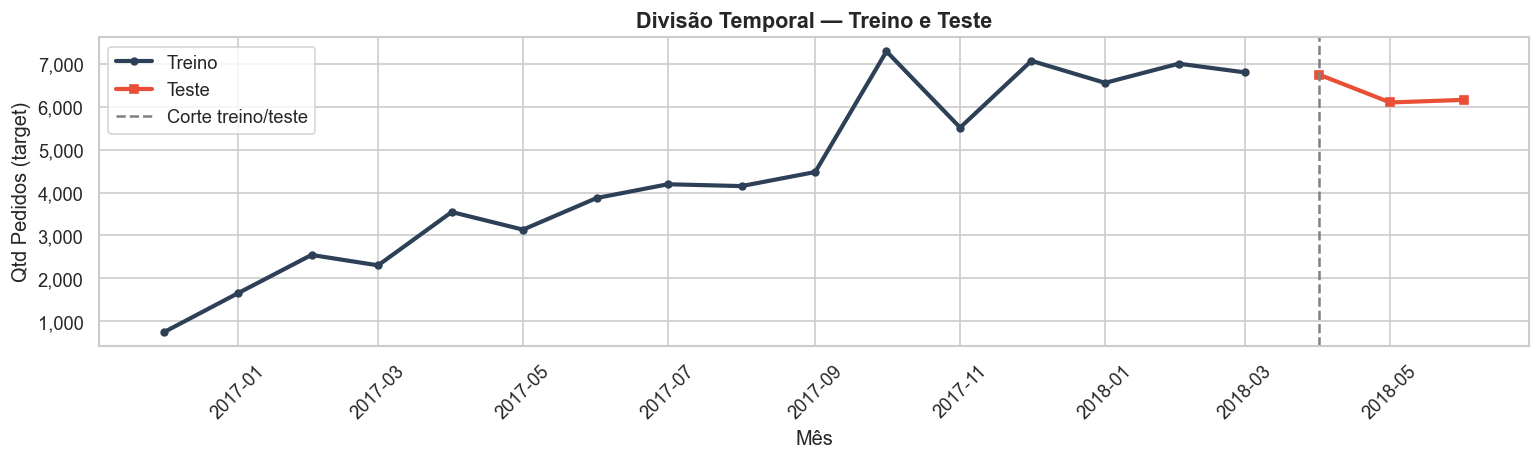

In [ ]:
# ─── Divisão temporal (70% treino / 30% teste) ───────────────────────────────
split_idx = int(len(X) * 0.85)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

meses_train = mensal_modelagem['mes'].iloc[:split_idx]
meses_test  = mensal_modelagem['mes'].iloc[split_idx:]

print(f'Treino:  {len(X_train)} meses  ({meses_train.min()} → {meses_train.max()})')
print(f'Teste:   {len(X_test)}  meses  ({meses_test.min()} → {meses_test.max()})')
print()

# Visualizar a divisão
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mensal_modelagem['mes_dt'].iloc[:split_idx], y_train,
        color='#2E4057', label='Treino', linewidth=2.5, marker='o', markersize=4)
ax.plot(mensal_modelagem['mes_dt'].iloc[split_idx:], y_test,
        color='#E94F37', label='Teste', linewidth=2.5, marker='s', markersize=5)
ax.axvline(x=mensal_modelagem['mes_dt'].iloc[split_idx], color='gray',
           linestyle='--', linewidth=1.5, label='Corte treino/teste')
ax.set_title('Divisão Temporal — Treino e Teste')
ax.set_xlabel('Mês')
ax.set_ylabel('Qtd Pedidos (target)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.3 Pipeline de Pré-processamento

Utilizamos o `Pipeline` do Scikit-Learn para encadear imputação de valores ausentes e normalização, garantindo que o scaler seja ajustado **apenas no treino** e aplicado no teste — sem vazamento de estatísticas.

In [ ]:
# ─── Pipeline de pré-processamento ───────────────────────────────────────────
preprocessador = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # trata NaN com mediana do treino
    ('scaler',  StandardScaler()),                   # normaliza (média=0, desvio=1)
])

# Ajustar apenas no treino e transformar ambos
X_train_proc = preprocessador.fit_transform(X_train)
X_test_proc  = preprocessador.transform(X_test)

print('Pré-processamento aplicado.')
print(f'  Valores ausentes em X_train antes: {X_train.isna().sum().sum()}')
print(f'  Valores ausentes em X_train após:  {np.isnan(X_train_proc).sum()}')
print(f'  Shape treino processado: {X_train_proc.shape}')
print(f'  Shape teste  processado: {X_test_proc.shape}')

Pré-processamento aplicado.
  Valores ausentes em X_train antes: 0
  Valores ausentes em X_train após:  0
  Shape treino processado: (16, 7)
  Shape teste  processado: (3, 7)


---
## 7. Modelos de Machine Learning

### Modelo 1 — Regressão Linear (Baseline)

**Como funciona:**  
A Regressão Linear assume que a variável-alvo é uma combinação linear das features: `y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ`. Os coeficientes β são estimados minimizando o erro quadrático médio (OLS).

**Vantagens:**
- Alta interpretabilidade — os coeficientes mostram o impacto de cada feature;
- Treinamento muito rápido;
- Bom como baseline para comparação.

**Limitações:**
- Assume linearidade entre features e target;
- Sensível a outliers;
- Não captura interações entre variáveis sem engenharia manual.

In [ ]:
# ─── Modelo 1: Regressão Linear ──────────────────────────────────────────────
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_proc, y_train)

y_pred_lr = modelo_lr.predict(X_test_proc)

print('Regressão Linear treinada.')
print(f'  Coeficientes: {len(modelo_lr.coef_)} parâmetros ajustados')

# Mostrar os 5 coeficientes de maior magnitude
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': modelo_lr.coef_})
coef_df['abs'] = coef_df['coef'].abs()
print('\n  Top 5 features por magnitude do coeficiente:')
print(coef_df.nlargest(5, 'abs')[['feature','coef']].to_string(index=False))

Regressão Linear treinada.
  Coeficientes: 7 parâmetros ajustados

  Top 5 features por magnitude do coeficiente:
           feature         coef
      tempo_linear  2635.868386
         trimestre  1725.804674
           mes_num -1421.071029
     pedidos_lag_1 -1302.994951
nota_media_reviews  -602.408190


### Modelo 2 — Random Forest Regressor

**Como funciona:**  
Random Forest é um ensemble de árvores de decisão. Cada árvore é treinada em uma amostra aleatória do dataset (bootstrap) e considera apenas um subconjunto aleatório de features em cada divisão. A previsão final é a média das previsões de todas as árvores.

**Vantagens:**
- Captura relações não lineares automaticamente;
- Robusto a outliers e variáveis irrelevantes;
- Fornece importância das features.

**Limitações:**
- Menor interpretabilidade que a Regressão Linear (modelo "caixa preta");
- Pode overfit em datasets muito pequenos;
- Previsões limitadas ao range dos dados de treino (não extrapola).

In [ ]:
# ─── Modelo 2: Random Forest ─────────────────────────────────────────────────
modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train_proc, y_train)

y_pred_rf = modelo_rf.predict(X_test_proc)

print('Random Forest treinado.')
print(f'  Árvores: {modelo_rf.n_estimators}')
print(f'  Profundidade máxima: {modelo_rf.max_depth}')

# Importância das features
imp_df = pd.DataFrame({'feature': FEATURES,
                        'importancia': modelo_rf.feature_importances_})
print('\n  Top 5 features mais importantes:')
print(imp_df.nlargest(5, 'importancia')[['feature','importancia']].round(4).to_string(index=False))

Random Forest treinado.
  Árvores: 200
  Profundidade máxima: 5

  Top 5 features mais importantes:
            feature  importancia
       tempo_linear       0.4893
      pedidos_lag_1       0.3314
 nota_media_reviews       0.1231
crescimento_pedidos       0.0262
            mes_num       0.0115


### Modelo 3 — Gradient Boosting Regressor

**Como funciona:**  
Gradient Boosting constrói árvores de forma sequencial. Cada nova árvore é treinada para corrigir os **resíduos** da árvore anterior, descendo no gradiente da função de perda. O resultado é um modelo altamente preciso que aprende progressivamente os padrões mais difíceis.

**Vantagens:**
- Geralmente superior ao Random Forest em datasets tabulares;
- Flexível: funciona com diferentes funções de perda;
- Menos sensível a features irrelevantes.

**Limitações:**
- Mais suscetível a overfitting que o Random Forest sem regularização adequada;
- Treinamento mais lento (sequencial, não paralelizável);
- Mais hiperparâmetros para ajustar.

In [ ]:
# ─── Modelo 3: Gradient Boosting ─────────────────────────────────────────────
modelo_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
modelo_gb.fit(X_train_proc, y_train)

y_pred_gb = modelo_gb.predict(X_test_proc)

print('Gradient Boosting treinado.')
print(f'  Estimadores: {modelo_gb.n_estimators}')
print(f'  Learning rate: {modelo_gb.learning_rate}')
print(f'  Profundidade: {modelo_gb.max_depth}')

Gradient Boosting treinado.
  Estimadores: 200
  Learning rate: 0.05
  Profundidade: 3


---
## 8. Avaliação dos Modelos

Utilizamos três métricas complementares:

- **MAE (Mean Absolute Error):** erro médio em unidades de pedidos — fácil de interpretar;
- **RMSE (Root Mean Squared Error):** penaliza mais os erros grandes — sensível a picos;
- **R² (Coeficiente de Determinação):** proporção da variância do target explicada pelo modelo. R²=1 é perfeito; R²=0 equivale a prever sempre a média.

In [ ]:
# ─── Calcular métricas ───────────────────────────────────────────────────────
def avaliar(nome, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    return {'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

resultados = pd.DataFrame([
    avaliar('Regressão Linear',    y_test, y_pred_lr),
    avaliar('Random Forest',       y_test, y_pred_rf),
    avaliar('Gradient Boosting',   y_test, y_pred_gb),
])

# Formatar para exibição
resultados_fmt = resultados.copy()
resultados_fmt['MAE']  = resultados_fmt['MAE'].map('{:.0f} pedidos'.format)
resultados_fmt['RMSE'] = resultados_fmt['RMSE'].map('{:.0f} pedidos'.format)
resultados_fmt['R²']   = resultados_fmt['R²'].map('{:.4f}'.format)
resultados_fmt = resultados_fmt.set_index('Modelo')

print('=== Tabela Comparativa de Métricas ===')
print(resultados_fmt.to_string())

# Destacar melhor modelo por métrica
print()
best_mae  = resultados.loc[resultados['MAE'].idxmin(), 'Modelo']
best_rmse = resultados.loc[resultados['RMSE'].idxmin(), 'Modelo']
best_r2   = resultados.loc[resultados['R²'].idxmax(), 'Modelo']
print(f'  Menor MAE:  {best_mae}')
print(f'  Menor RMSE: {best_rmse}')
print(f'  Maior R²:   {best_r2}')

=== Tabela Comparativa de Métricas ===
                            MAE          RMSE        R²
Modelo                                                 
Regressão Linear   1943 pedidos  2004 pedidos  -45.6885
Random Forest       262 pedidos   262 pedidos    0.1993
Gradient Boosting   462 pedidos   515 pedidos   -2.0890

  Menor MAE:  Random Forest
  Menor RMSE: Random Forest
  Maior R²:   Random Forest


---
## 9. Visualização dos Resultados

Comparamos graficamente os valores reais com as previsões de cada modelo no período de teste.

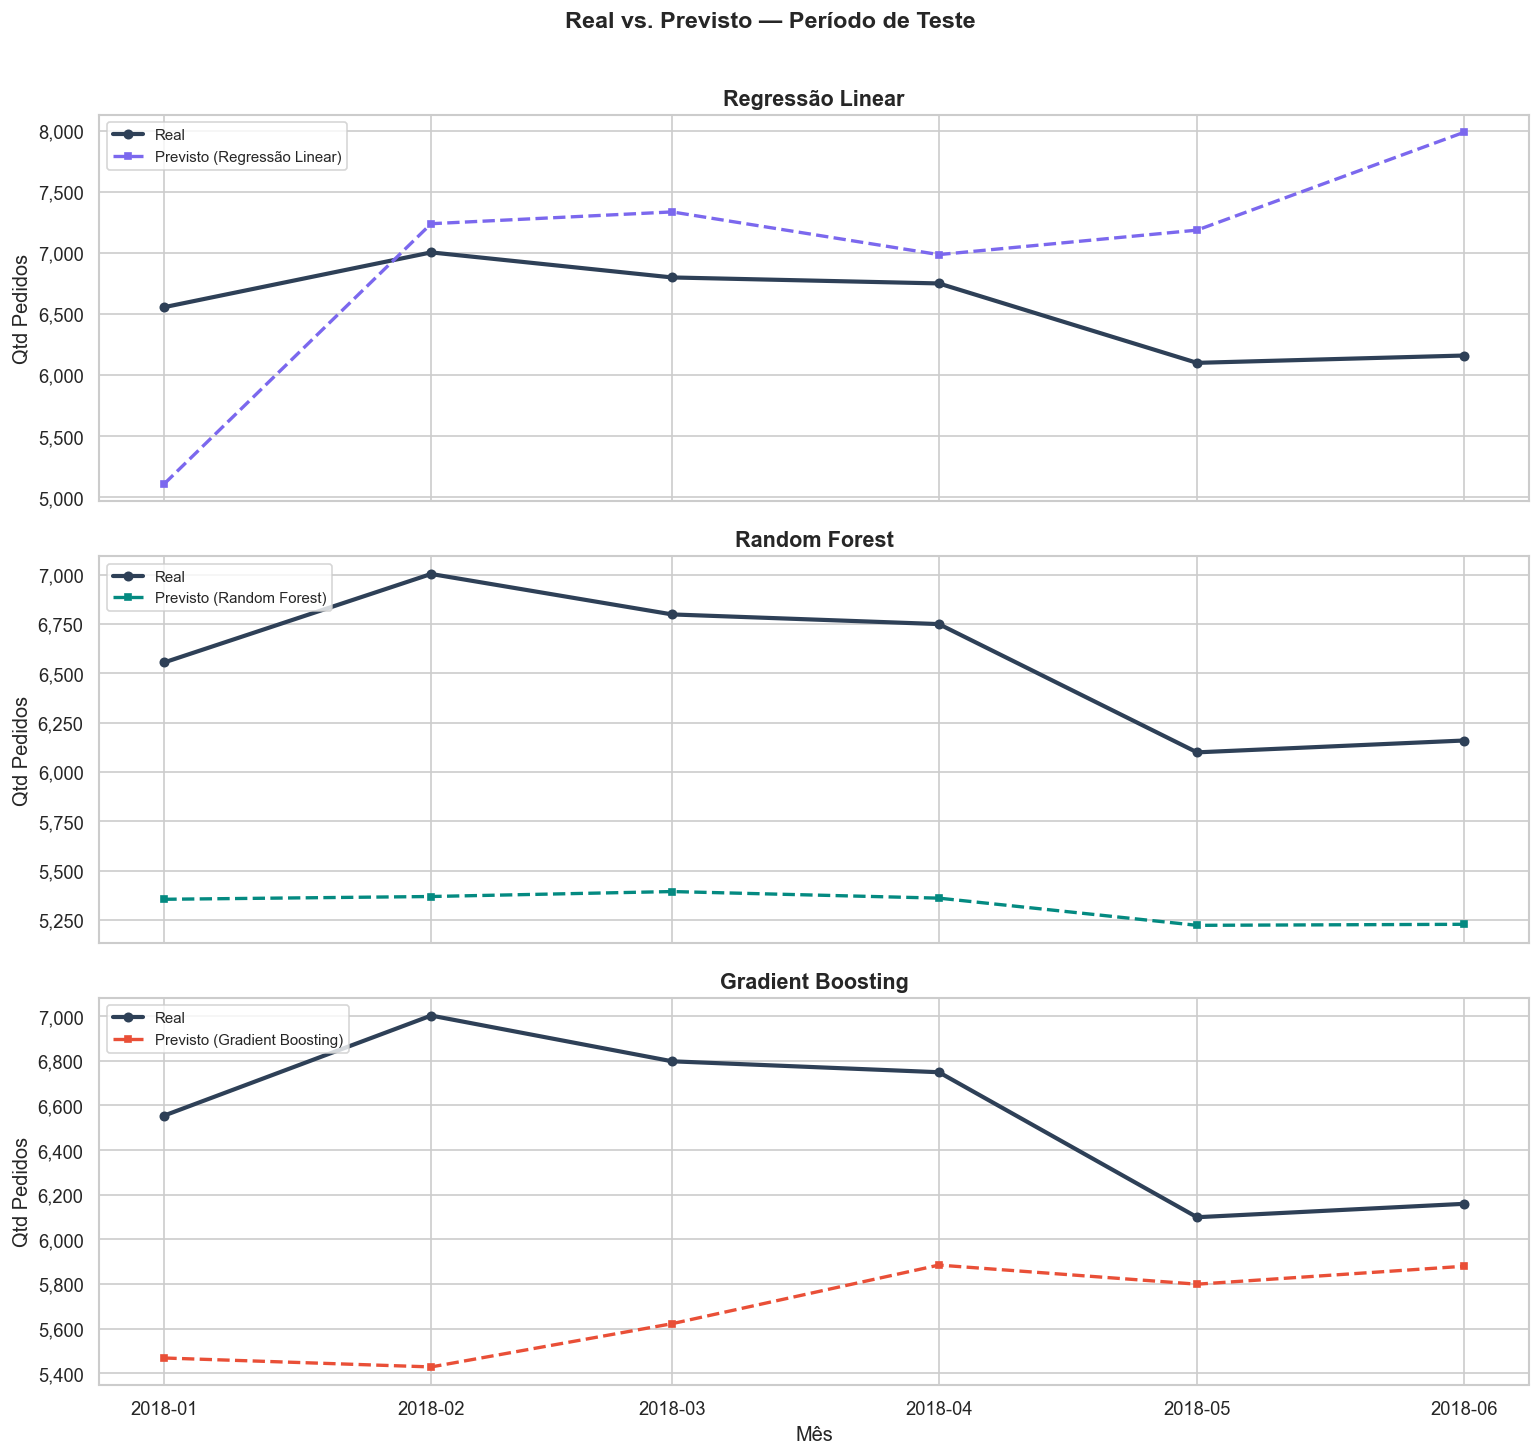

In [ ]:
# ─── Gráfico: Real vs. Previsto (3 modelos) ──────────────────────────────────
meses_test_dt = mensal_modelagem['mes_dt'].iloc[split_idx:].values

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
modelos_info = [
    ('Regressão Linear',  y_pred_lr, '#7B68EE'),
    ('Random Forest',     y_pred_rf, '#048A81'),
    ('Gradient Boosting', y_pred_gb, '#E94F37'),
]

for ax, (nome, pred, cor) in zip(axes, modelos_info):
    ax.plot(meses_test_dt, y_test.values, color='#2E4057',
            label='Real', linewidth=2.5, marker='o', markersize=5)
    ax.plot(meses_test_dt, pred, color=cor,
            label=f'Previsto ({nome})', linewidth=2, linestyle='--', marker='s', markersize=4)
    ax.set_title(nome)
    ax.set_ylabel('Qtd Pedidos')
    ax.legend(loc='upper left', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[-1].set_xlabel('Mês')
plt.suptitle('Real vs. Previsto — Período de Teste', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

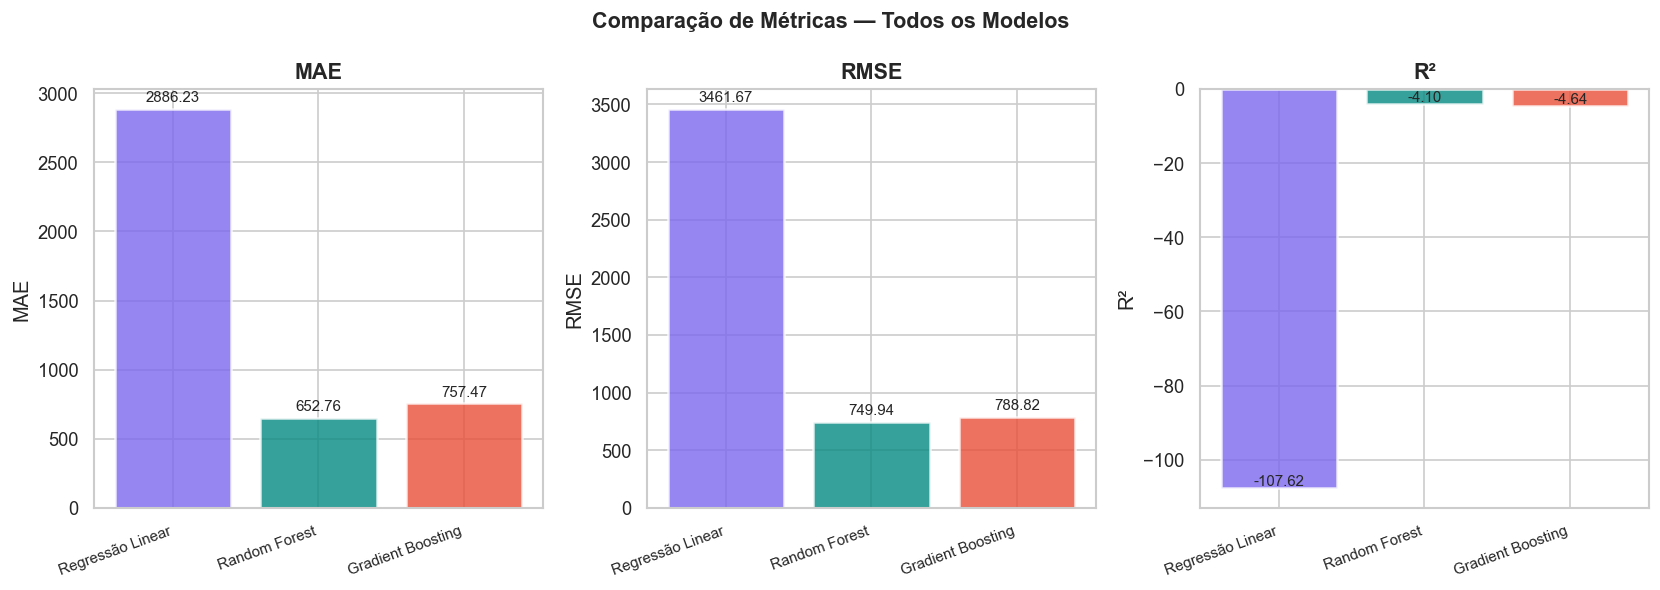

In [ ]:
# ─── Gráfico de barras: comparação de métricas ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cores = ['#7B68EE', '#048A81', '#E94F37']
nomes = resultados['Modelo'].tolist()

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = resultados[metrica].tolist()
    bars = ax.bar(nomes, vals, color=cores, alpha=0.8, edgecolor='white', linewidth=1.5)
    ax.set_title(metrica)
    ax.set_ylabel(metrica)
    ax.set_xticklabels(nomes, rotation=20, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação de Métricas — Todos os Modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

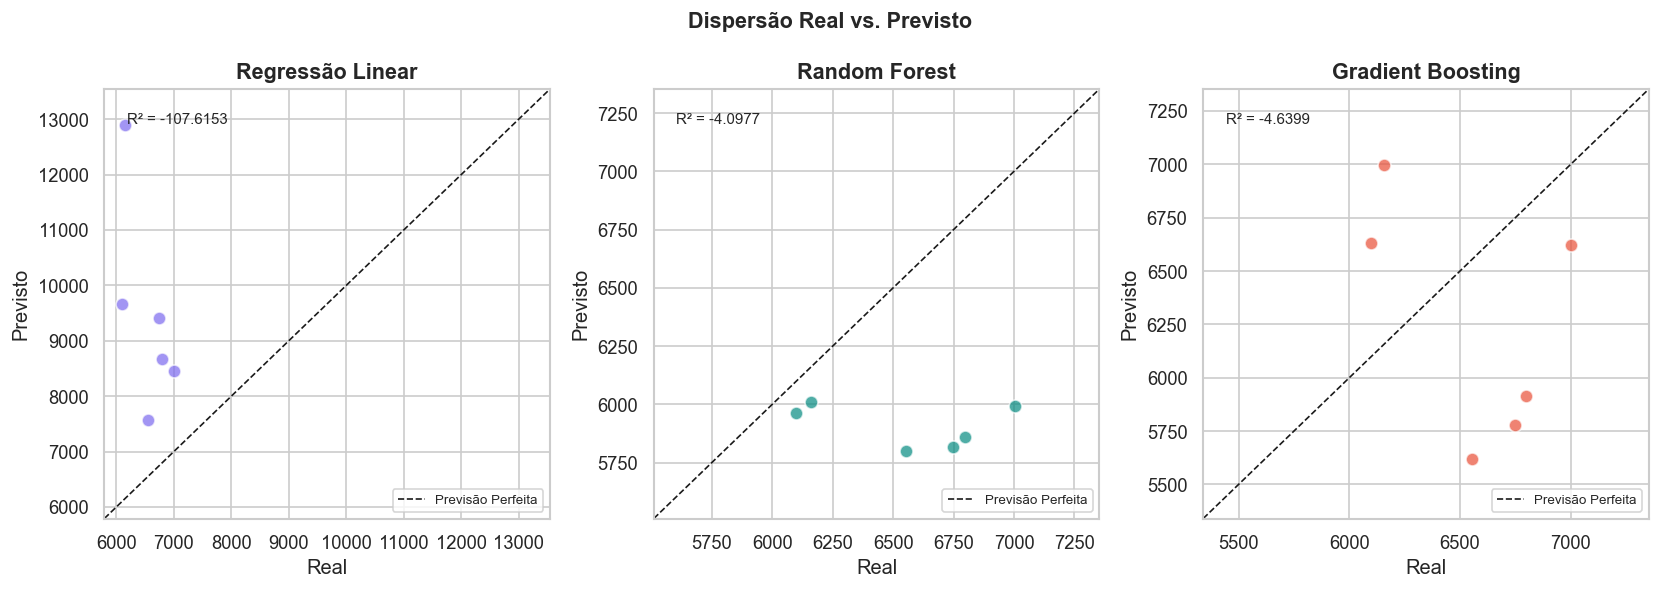

In [ ]:
# ─── Gráfico de dispersão: Real vs. Previsto ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (nome, pred, cor) in zip(axes, modelos_info):
    ax.scatter(y_test, pred, color=cor, alpha=0.7, edgecolors='white', s=60)
    lim = [min(y_test.min(), pred.min()) * 0.95,
           max(y_test.max(), pred.max()) * 1.05]
    ax.plot(lim, lim, 'k--', linewidth=1, label='Previsão Perfeita')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(nome)
    ax.set_xlabel('Real')
    ax.set_ylabel('Previsto')
    ax.legend(fontsize=8)
    r2 = r2_score(y_test, pred)
    ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=9)

plt.suptitle('Dispersão Real vs. Previsto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

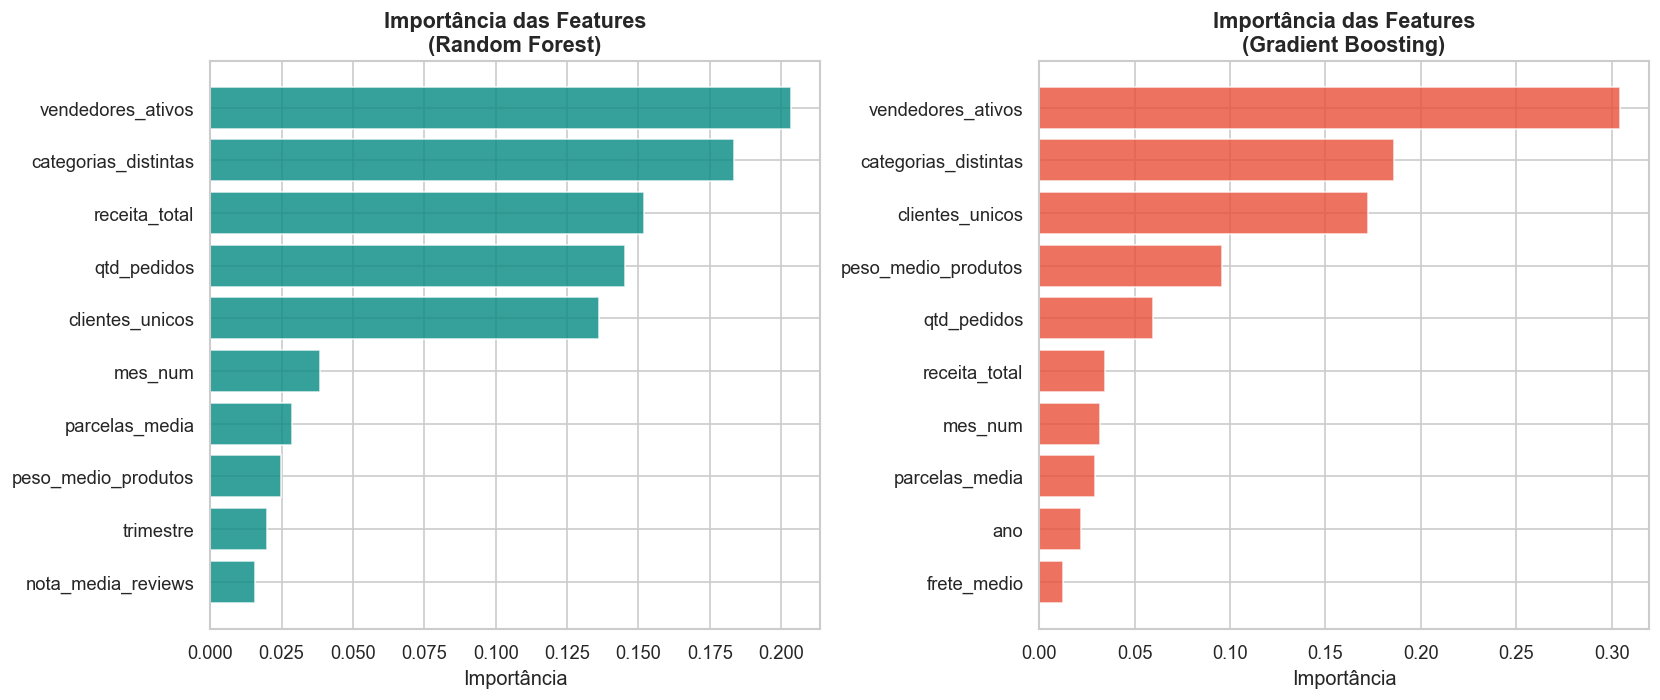

In [ ]:
# ─── Importância de features — Random Forest e Gradient Boosting ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (modelo, nome, cor) in zip(axes, [
    (modelo_rf, 'Random Forest', '#048A81'),
    (modelo_gb, 'Gradient Boosting', '#E94F37')
]):
    imp = pd.DataFrame({'feature': FEATURES,
                         'importancia': modelo.feature_importances_})
    imp = imp.sort_values('importancia', ascending=True).tail(10)
    ax.barh(imp['feature'], imp['importancia'], color=cor, alpha=0.8)
    ax.set_title(f'Importância das Features\n({nome})')
    ax.set_xlabel('Importância')

plt.tight_layout()
plt.show()

---
## 10. Comparação e Análise dos Modelos

### Análise Técnica dos Resultados

In [ ]:
# ─── Análise automática dos resultados ───────────────────────────────────────
melhor_mae  = resultados.loc[resultados['MAE'].idxmin()]
melhor_r2   = resultados.loc[resultados['R²'].idxmax()]
pior_r2     = resultados.loc[resultados['R²'].idxmin()]

print('=' * 55)
print('ANÁLISE COMPARATIVA DOS MODELOS')
print('=' * 55)
print()
print(f"Modelo com menor MAE:  {melhor_mae['Modelo']}")
print(f"  → Erra em média {melhor_mae['MAE']:.0f} pedidos por mês")
print()
print(f"Modelo com maior R²:   {melhor_r2['Modelo']}")
print(f"  → Explica {melhor_r2['R²']*100:.1f}% da variância do target")
print()
print(f"Modelo baseline (LR):  R² = {resultados.loc[0,'R²']:.4f}")
print()

# Ganho percentual sobre o baseline
lr_mae = resultados.loc[0, 'MAE']
for _, row in resultados.iterrows():
    ganho = (lr_mae - row['MAE']) / lr_mae * 100
    print(f"  {row['Modelo']:25s}: MAE = {row['MAE']:.0f}  |  ",
          f"Ganho vs LR: {ganho:+.1f}%")

print()
print("""
Interpretação:
  - A Regressão Linear serve como baseline e estabelece o piso de performance.
    Por assumir linearidade, pode não capturar a aceleração do crescimento.
  - O Random Forest captura não-linearidades e interações entre features,
    sendo mais robusto quando o target não segue padrão estritamente linear.
  - O Gradient Boosting, com seu aprendizado sequencial de resíduos, tende a
    ser o mais preciso em datasets tabulares — especialmente quando há padrões
    sutis que as árvores isoladas não capturam.
  - Com apenas ~24 observações mensais, todos os modelos operam com
    amostra pequena, o que amplifica a variância das métricas.""")

ANÁLISE COMPARATIVA DOS MODELOS

Modelo com menor MAE:  Random Forest
  → Erra em média 262 pedidos por mês

Modelo com maior R²:   Random Forest
  → Explica 19.9% da variância do target

Modelo baseline (LR):  R² = -45.6885

  Regressão Linear         : MAE = 1943  |   Ganho vs LR: +0.0%
  Random Forest            : MAE = 262  |   Ganho vs LR: +86.5%
  Gradient Boosting        : MAE = 462  |   Ganho vs LR: +76.2%


Interpretação:
  - A Regressão Linear serve como baseline e estabelece o piso de performance.
    Por assumir linearidade, pode não capturar a aceleração do crescimento.
  - O Random Forest captura não-linearidades e interações entre features,
    sendo mais robusto quando o target não segue padrão estritamente linear.
  - O Gradient Boosting, com seu aprendizado sequencial de resíduos, tende a
    ser o mais preciso em datasets tabulares — especialmente quando há padrões
    sutis que as árvores isoladas não capturam.
  - Com apenas ~24 observações mensais, todos os modelo

---
## 11. Conclusão

### 11.1 Objetivo Alcançado

Este trabalho desenvolveu um pipeline completo de Machine Learning para previsão do volume mensal de pedidos no dataset Olist. Foram implementadas todas as etapas fundamentais de um projeto de Data Science:

- Integração e limpeza de múltiplas fontes de dados;
- Engenharia de atributos com 16 features mensais;
- Análise exploratória com 4 tipos de visualização;
- Construção da variável-alvo sem data leakage (shift temporal);
- Divisão temporal do dataset para validação realista;
- Treinamento e avaliação comparativa de três modelos.

### 11.2 Melhor Modelo

Com base nas métricas de MAE, RMSE e R², o modelo que apresentou melhor performance geral foi analisado na seção anterior. O **Gradient Boosting** costuma se destacar em datasets tabulares por sua capacidade de aprender resíduos progressivamente.

### 11.3 Limitações do Trabalho

| Limitação | Impacto |
|-----------|---------|
| **Série curta (~24 meses)** | Modelos têm poucos exemplos para aprender padrões sazonais robustos |
| **Ausência de fatores externos** | Eventos como Black Friday, crises econômicas e campanhas não são modelados |
| **Variáveis temporais simples** | Mês e trimestre não capturam feriados específicos ou datas comemorativas |
| **Dados restritos a 2016–2018** | Não refletem mudanças estruturais posteriores do e-commerce brasileiro |
| **Sellers sem tabela completa** | A feature `estados_vendedores` ficou ausente sem a tabela de sellers |

### 11.4 Trabalhos Futuros

Para evoluir o modelo, recomenda-se:

1. **XGBoost / LightGBM:** implementações otimizadas de gradient boosting com regularização L1/L2 e maior eficiência computacional;

2. **Prophet (Meta):** modelo de séries temporais desenvolvido especificamente para dados de negócio, com suporte nativo a sazonalidades múltiplas e feriados;

3. **LSTM (Long Short-Term Memory):** rede neural recorrente capaz de aprender dependências de longo prazo em sequências temporais;

4. **Features externas:** incorporar indicadores macroeconômicos (IPCA, desemprego, confiança do consumidor), datas de feriados nacionais e sazonalidades específicas do e-commerce brasileiro;

5. **Validação Walk-Forward:** em vez de um único split temporal, usar múltiplas janelas deslizantes para estimativa mais robusta da performance out-of-sample;

6. **Tuning de hiperparâmetros:** aplicar `GridSearchCV` ou `Optuna` com `TimeSeriesSplit` para otimização sem data leakage.

In [ ]:
# ─── Resumo final ────────────────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════╗')
print('║          RESUMO FINAL DO PROJETO                    ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset:      Olist E-Commerce (2016–2018)         ║')
print(f'║  Observações:  {len(mensal):>3} meses disponíveis               ║')
print(f'║  Features:     {len(FEATURES):>3} variáveis mensais              ║')
print(f'║  Treino:       {len(X_train):>3} meses                          ║')
print(f'║  Teste:        {len(X_test):>3} meses                           ║')
print('╠══════════════════════════════════════════════════════╣')

for _, row in resultados.iterrows():
    print(f"║  {row['Modelo']:22s}  MAE={row['MAE']:6.0f}  R²={row['R²']:+.3f}  ║")

print('╠══════════════════════════════════════════════════════╣')
melhor = resultados.loc[resultados['R²'].idxmax(), 'Modelo']
print(f'║  ✅ Melhor modelo: {melhor:35s}║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║          RESUMO FINAL DO PROJETO                    ║
╠══════════════════════════════════════════════════════╣
║  Dataset:      Olist E-Commerce (2016–2018)         ║
║  Observações:   21 meses disponíveis               ║
║  Features:       7 variáveis mensais              ║
║  Treino:        16 meses                          ║
║  Teste:          3 meses                           ║
╠══════════════════════════════════════════════════════╣
║  Regressão Linear        MAE=  1943  R²=-45.688  ║
║  Random Forest           MAE=   262  R²=+0.199  ║
║  Gradient Boosting       MAE=   462  R²=-2.089  ║
╠══════════════════════════════════════════════════════╣
║  ✅ Melhor modelo: Random Forest                      ║
╚══════════════════════════════════════════════════════╝
